# Group 8 — People Analytics: Who's a Flight Risk?
### Data Understanding, Cleaning & Exploratory Data Analysis

**Dataset:** IBM HR Analytics Employee Attrition
**Goal:** Understand and clean the raw data, then explore what patterns relate to attrition,
before moving on to clustering and predictive modelling.


## 1. Import libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("charts", exist_ok=True)
sns.set_style("whitegrid")
%matplotlib inline


## 2. Load raw dataset

In [2]:
df = pd.read_csv("Employee-Attrition.csv")
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset loaded: 1470 rows, 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 3. Data Understanding

We look at the raw data before touching anything, so every cleaning decision
later is based on evidence, not guesswork.

### 3.1 Shape

In [3]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")


Shape: 1470 rows, 35 columns


### 3.2 Data types

In [4]:
df.dtypes


Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

### 3.3 Unique values

In [5]:
df.nunique().sort_values()


Over18                         1
StandardHours                  1
EmployeeCount                  1
Gender                         2
Attrition                      2
PerformanceRating              2
OverTime                       2
MaritalStatus                  3
Department                     3
BusinessTravel                 3
StockOptionLevel               4
EnvironmentSatisfaction        4
JobInvolvement                 4
JobSatisfaction                4
RelationshipSatisfaction       4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

### 3.4 Descriptive statistics

In [6]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


## 4. Data Cleaning

Steps: check for missing values, duplicates, constant columns, ID columns,
outliers, then encode text columns into numbers.

### 4.1 Missing values

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(f"Columns with missing values: {len(missing)}")
missing


Columns with missing values: 0


Series([], dtype: int64)

### 4.2 Duplicates

In [8]:
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")
df = df.drop_duplicates()


Duplicate rows: 0


### 4.3 Constant columns

A constant column has the exact same value for every employee, so it carries
zero information for prediction or clustering.

In [9]:
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constant columns (same value everywhere): {constant_columns}")


Constant columns (same value everywhere): ['EmployeeCount', 'Over18', 'StandardHours']


### 4.4 ID columns

`EmployeeNumber` is just a name tag, not a real feature — it gets dropped too.

In [10]:
id_columns = ["EmployeeNumber"] if "EmployeeNumber" in df.columns else []
print(f"ID columns to drop: {id_columns}")

df = df.drop(columns=constant_columns + id_columns)
print(f"Shape after dropping constant/ID columns: {df.shape}")


ID columns to drop: ['EmployeeNumber']
Shape after dropping constant/ID columns: (1470, 31)


### 4.5 Outlier investigation

We use boxplots to visually check every numeric column for extreme values.

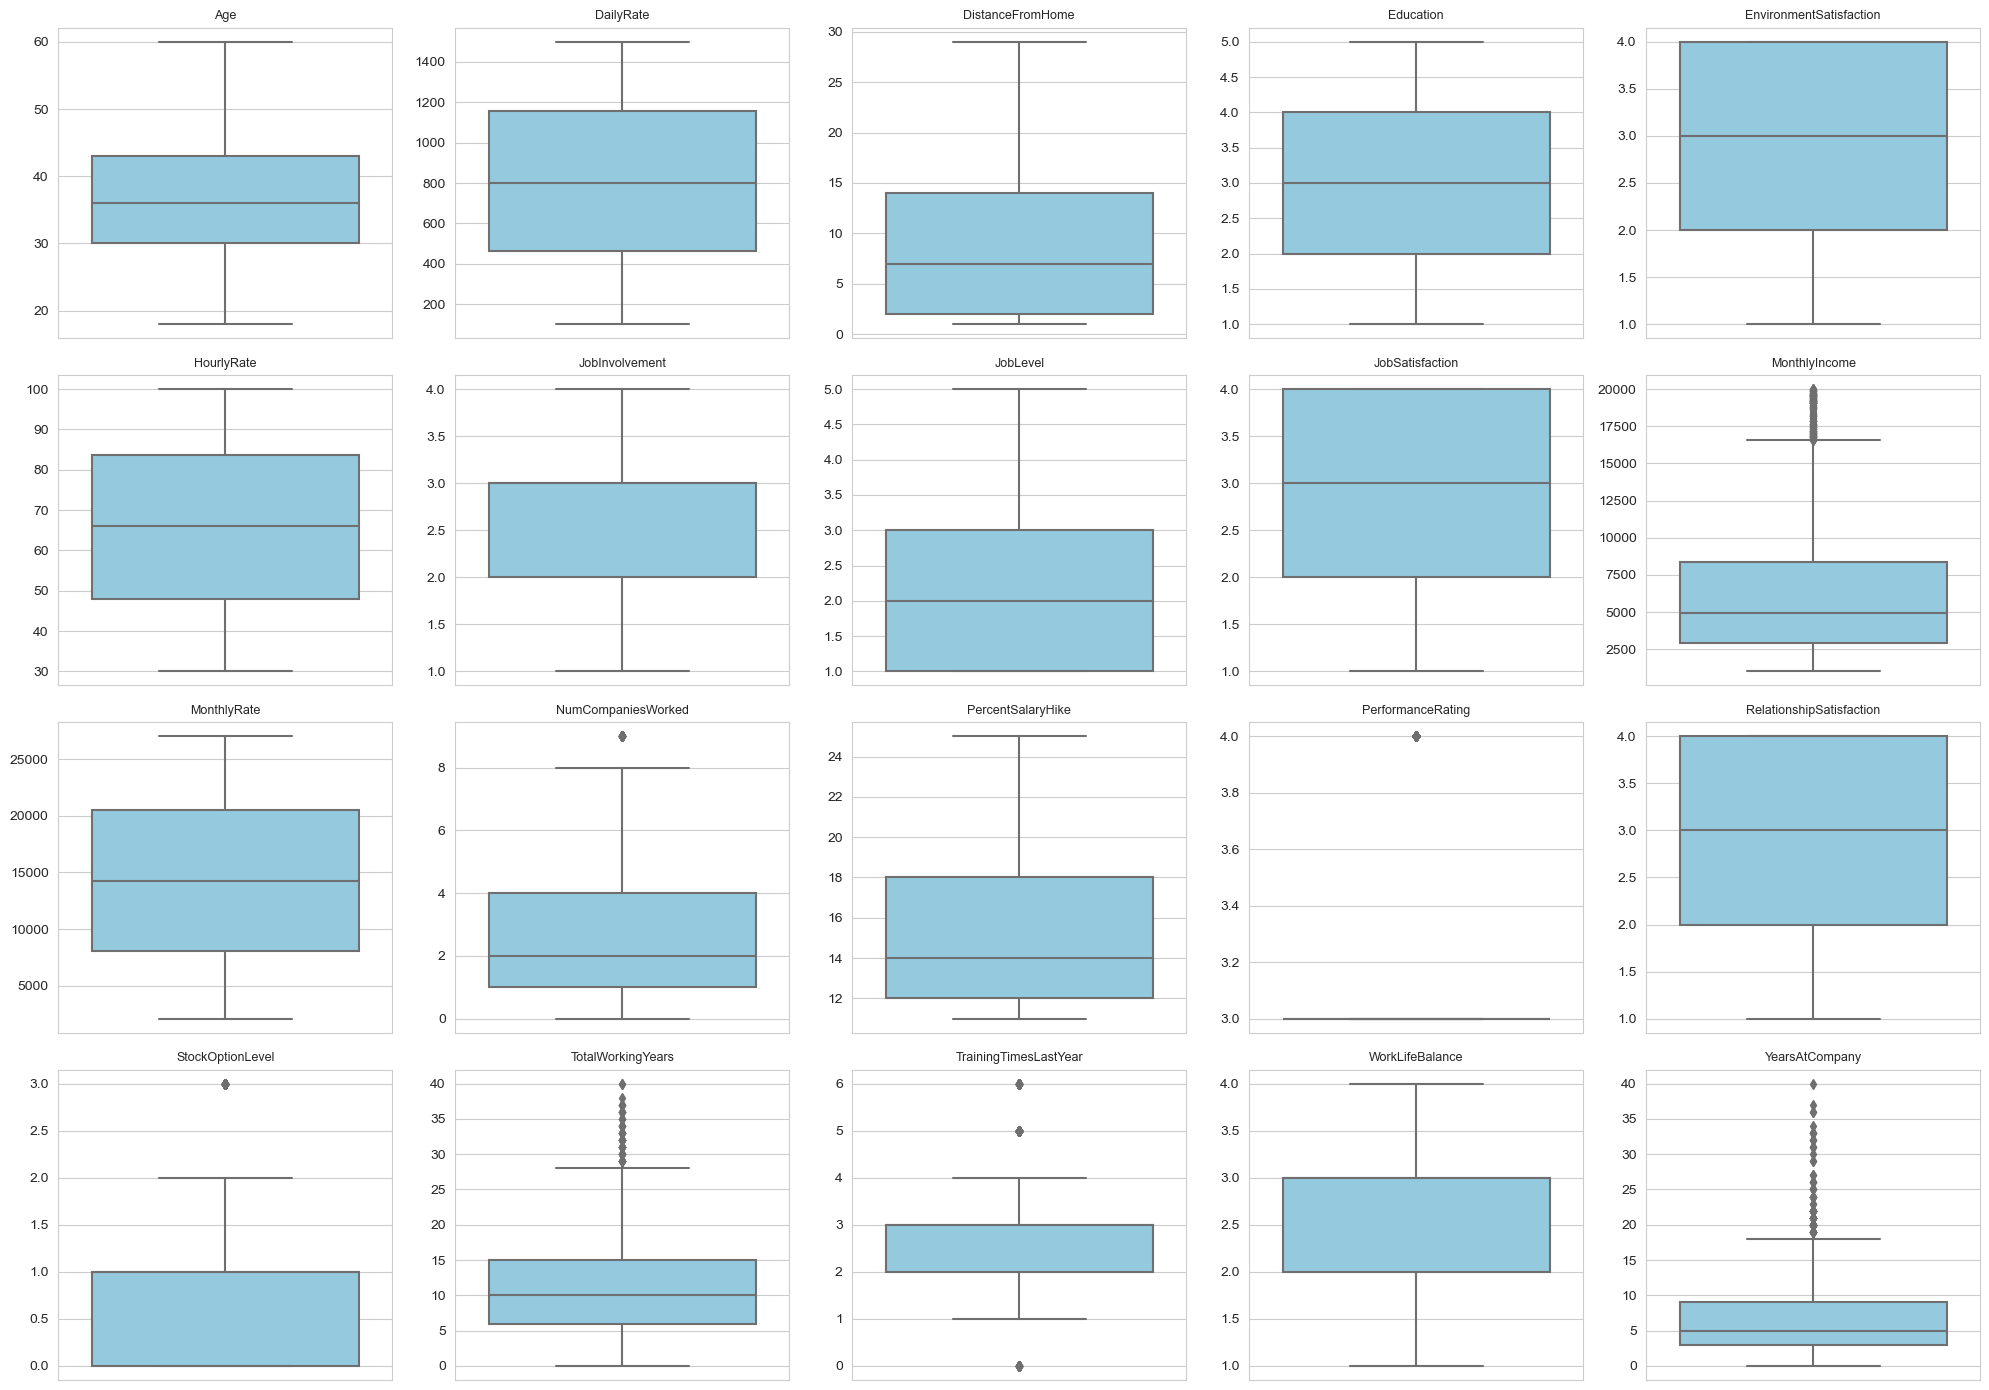

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:20]):
    sns.boxplot(y=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("")
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig("charts/01_outlier_boxplots.png", dpi=150)
plt.show()


**Reading this chart:** columns like `MonthlyIncome`, `YearsAtCompany` and
`TotalWorkingYears` show some high values (long-tenured, high-earning employees).
These are real people, not data errors, so we keep them — but it's worth
mentioning in the report that they exist.

### 4.6 Encoding

In [12]:
# Convert simple Yes/No columns into 1/0
yes_no_columns = ["Attrition", "OverTime"]
for col in yes_no_columns:
    if col in df.columns:
        df[col] = df[col].map({"Yes": 1, "No": 0})

# One-hot encode the remaining multi-category columns
categorical_columns = df.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns encoded: {categorical_columns}")

df_clean = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
print(f"Final cleaned shape: {df_clean.shape}")

df_clean.to_csv("Employee-Attrition-Clean.csv", index=False)
print("Saved Employee-Attrition-Clean.csv")


Categorical columns encoded: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']
Final cleaned shape: (1470, 45)
Saved Employee-Attrition-Clean.csv


## 5. Exploratory Data Analysis

For readability, charts use the pre-encoding version of the data (plain text
labels like "Yes"/"No" and department names), while the correlation heatmap
uses the fully encoded numeric version.

In [13]:
df_eda = df.copy()
df_eda["Attrition"] = df_eda["Attrition"].map({1: "Yes", 0: "No"})


### 5.1 Attrition distribution

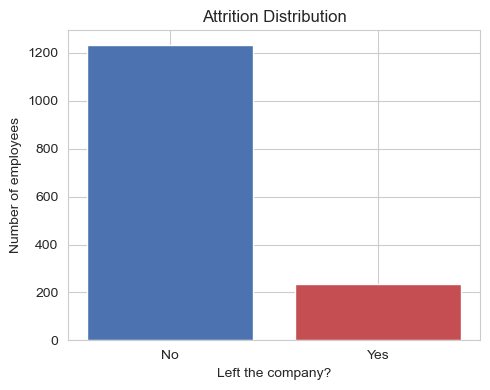

Attrition rate: 16.1%


In [14]:
plt.figure(figsize=(5, 4))
order = ["No", "Yes"]
colors_map = {"No": "#4C72B0", "Yes": "#C44E52"}
counts = df_eda["Attrition"].value_counts().reindex(order)

plt.bar(order, counts.values, color=[colors_map[o] for o in order])
plt.title("Attrition Distribution")
plt.xlabel("Left the company?")
plt.ylabel("Number of employees")
plt.tight_layout()
plt.savefig("charts/02_attrition_distribution.png", dpi=150)
plt.show()

rate = df_eda["Attrition"].value_counts(normalize=True)["Yes"]
print(f"Attrition rate: {rate:.1%}")


**Reading this chart:** the dataset is imbalanced — far fewer employees
left than stayed. This is why accuracy alone would be a misleading metric
later; we'll need F1 / PR-AUC for the supervised models.

### 5.2 Numerical distributions

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

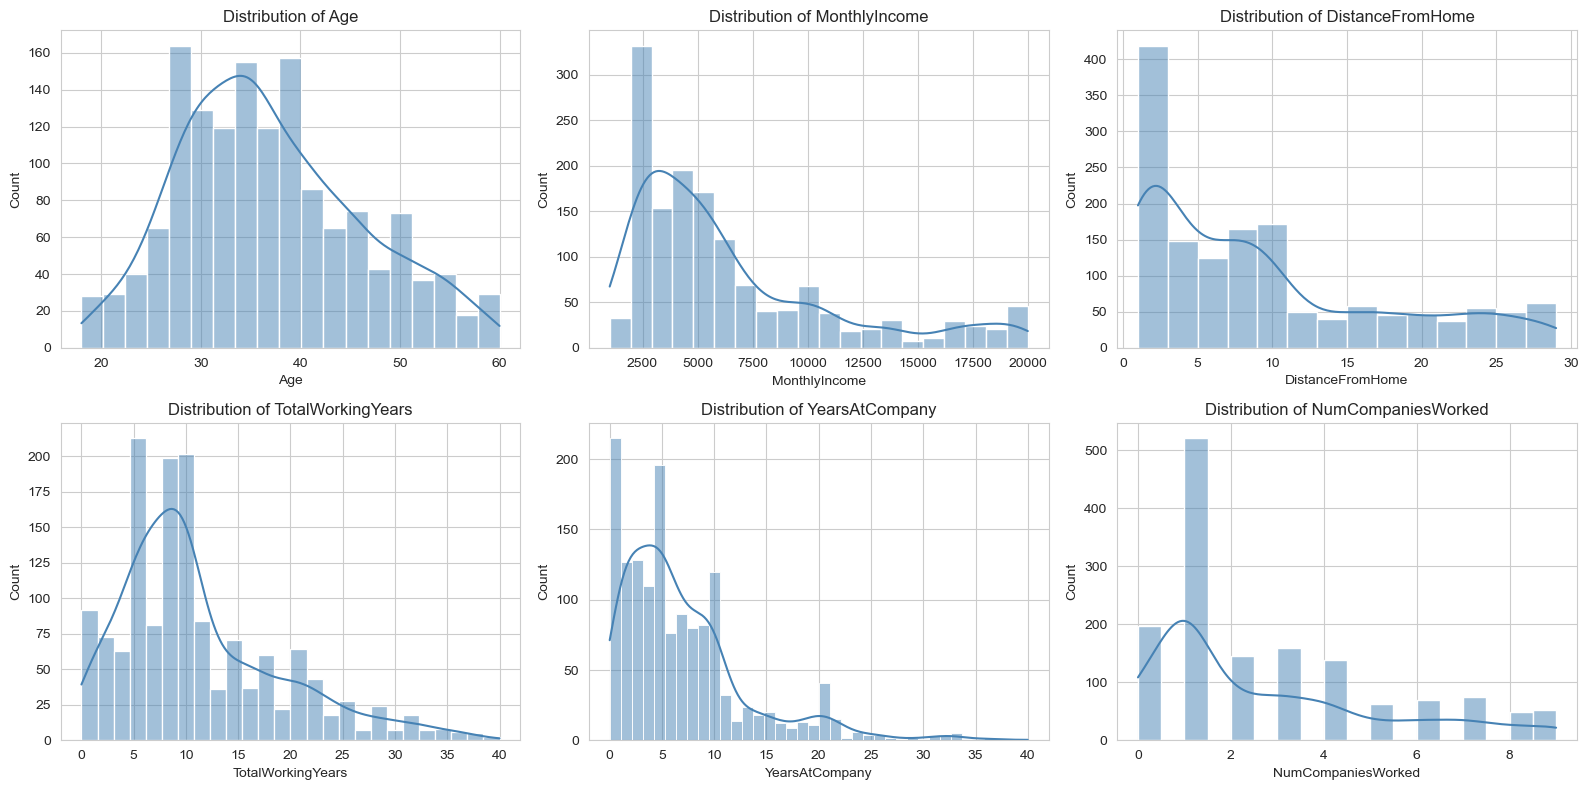

In [15]:
key_numeric = ["Age", "MonthlyIncome", "DistanceFromHome", "TotalWorkingYears",
                "YearsAtCompany", "NumCompaniesWorked"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(key_numeric):
    sns.histplot(df_eda[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("charts/03_numerical_distributions.png", dpi=150)
plt.show()


### 5.3 Categorical vs Attrition

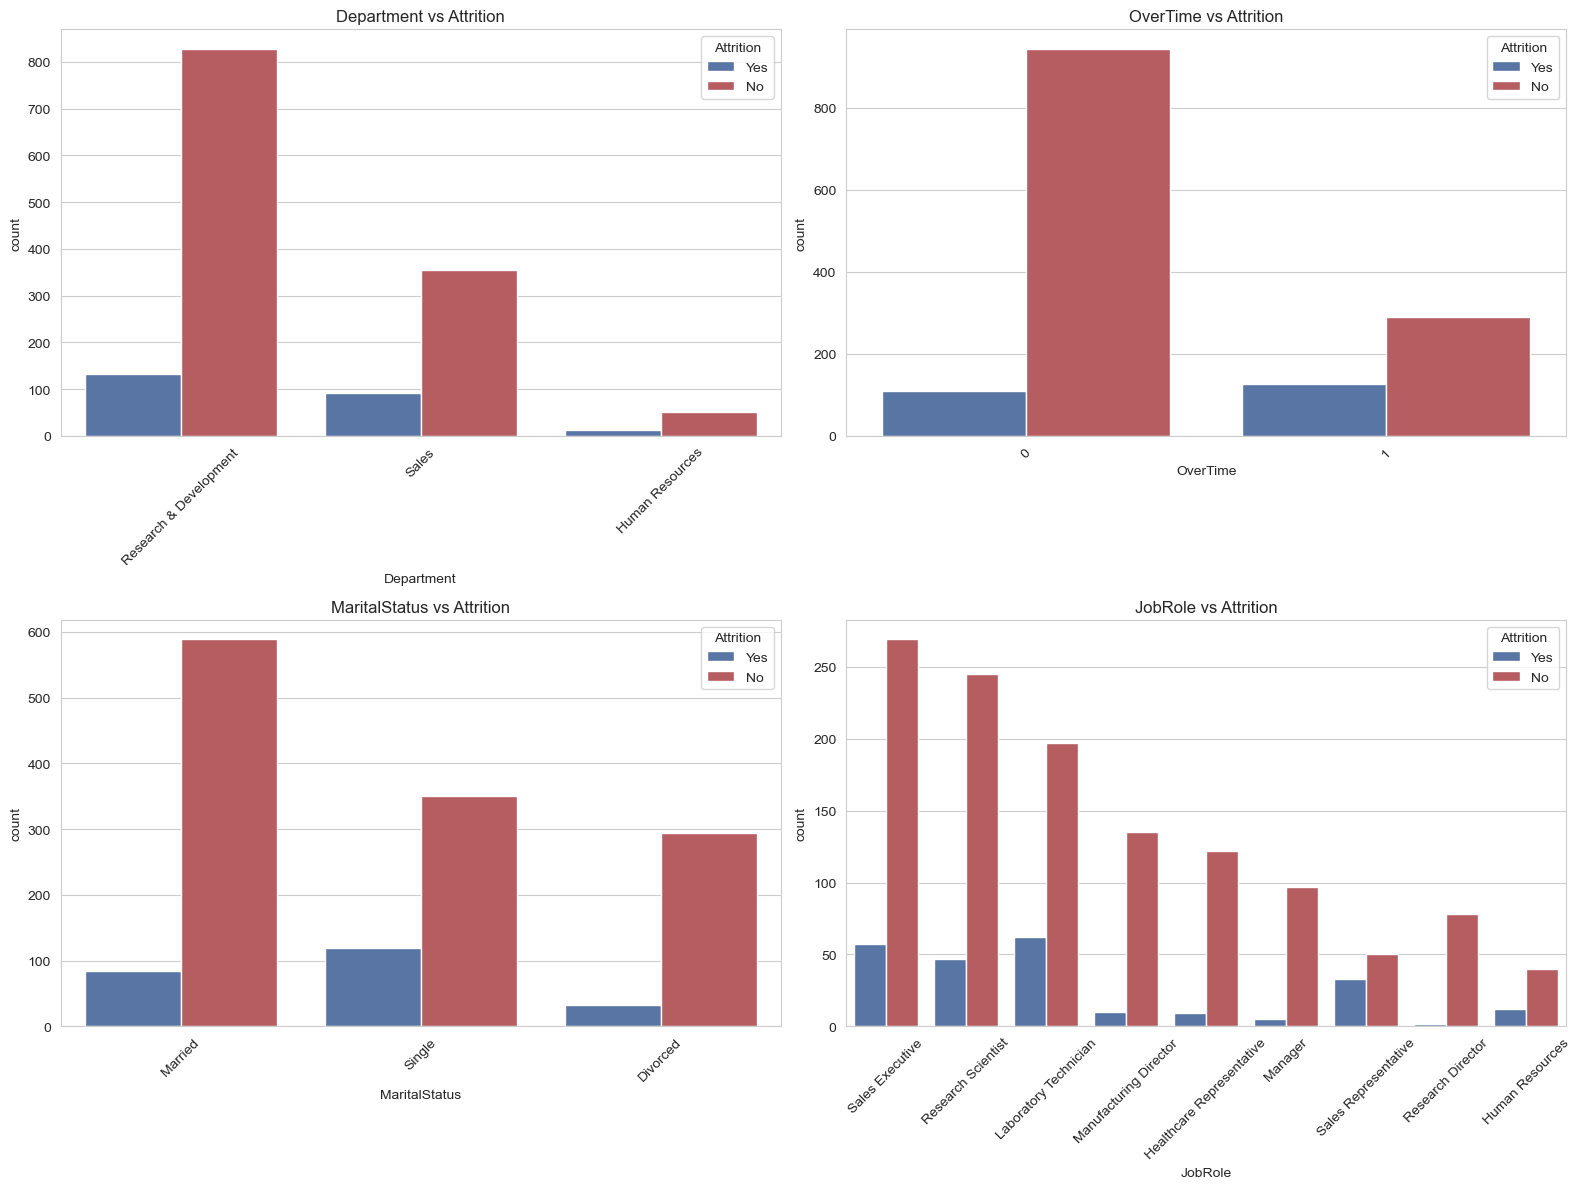

In [16]:
key_categorical = ["Department", "OverTime", "MaritalStatus", "JobRole"]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(key_categorical):
    order = df_eda[col].value_counts().index
    sns.countplot(data=df_eda, x=col, hue="Attrition", ax=axes[i], order=order,
                  palette=["#4C72B0", "#C44E52"])
    axes[i].set_title(f"{col} vs Attrition")
    axes[i].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("charts/04_categorical_vs_attrition.png", dpi=150)
plt.show()


**Reading this chart:** watch for categories where the red ("Yes") share
looks noticeably bigger — e.g. employees who work overtime tend to show a
higher share of attrition than those who don't.

### 5.4 Numerical vs Attrition

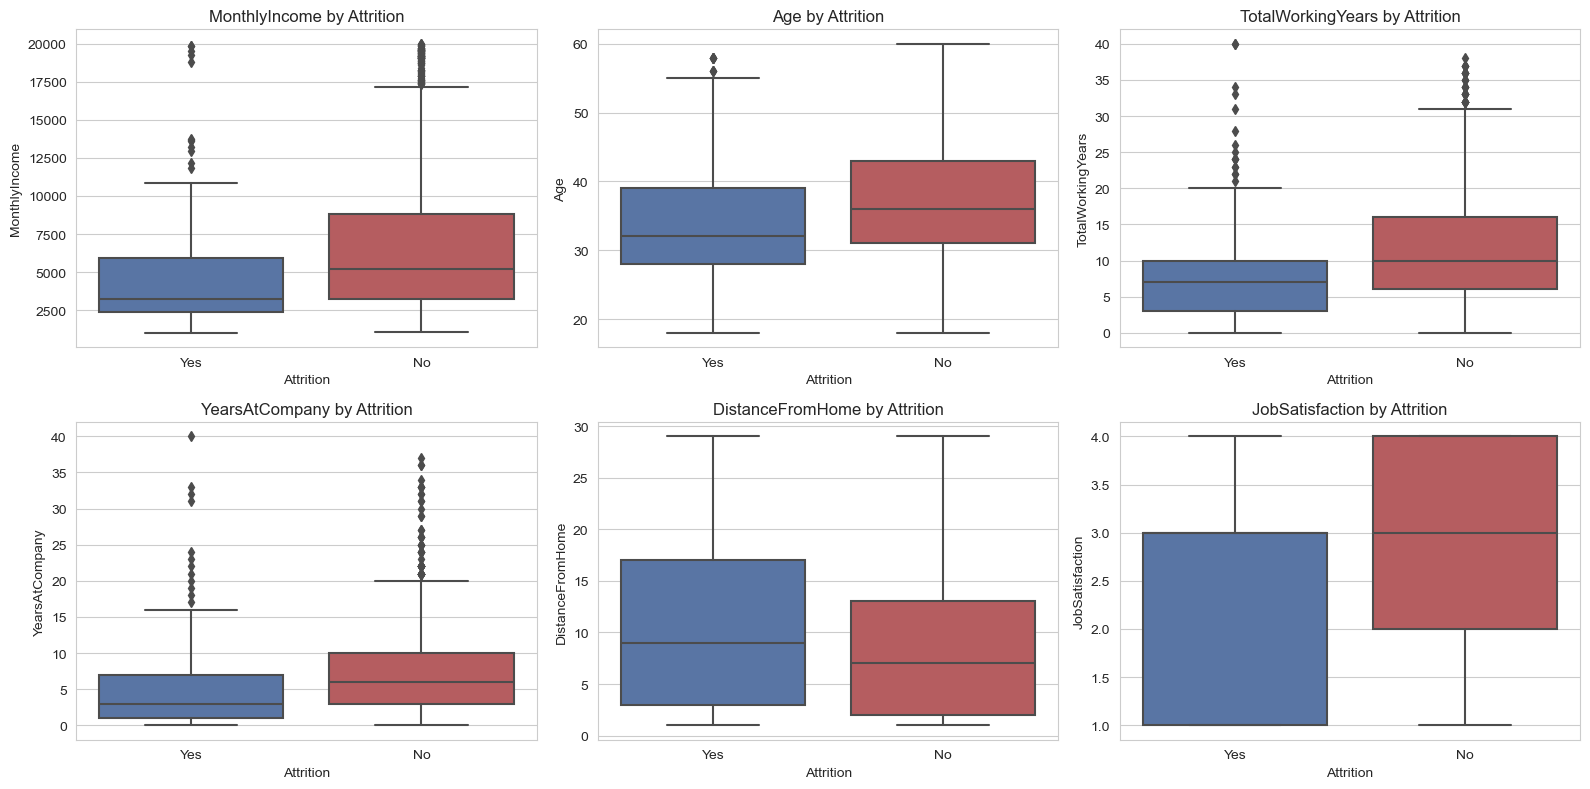

In [17]:
key_numeric_2 = ["MonthlyIncome", "Age", "TotalWorkingYears",
                  "YearsAtCompany", "DistanceFromHome", "JobSatisfaction"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(key_numeric_2):
    sns.boxplot(data=df_eda, x="Attrition", y=col, ax=axes[i],
                palette=["#4C72B0", "#C44E52"])
    axes[i].set_title(f"{col} by Attrition")
plt.tight_layout()
plt.savefig("charts/05_numerical_vs_attrition.png", dpi=150)
plt.show()


### 5.5 Correlation analysis

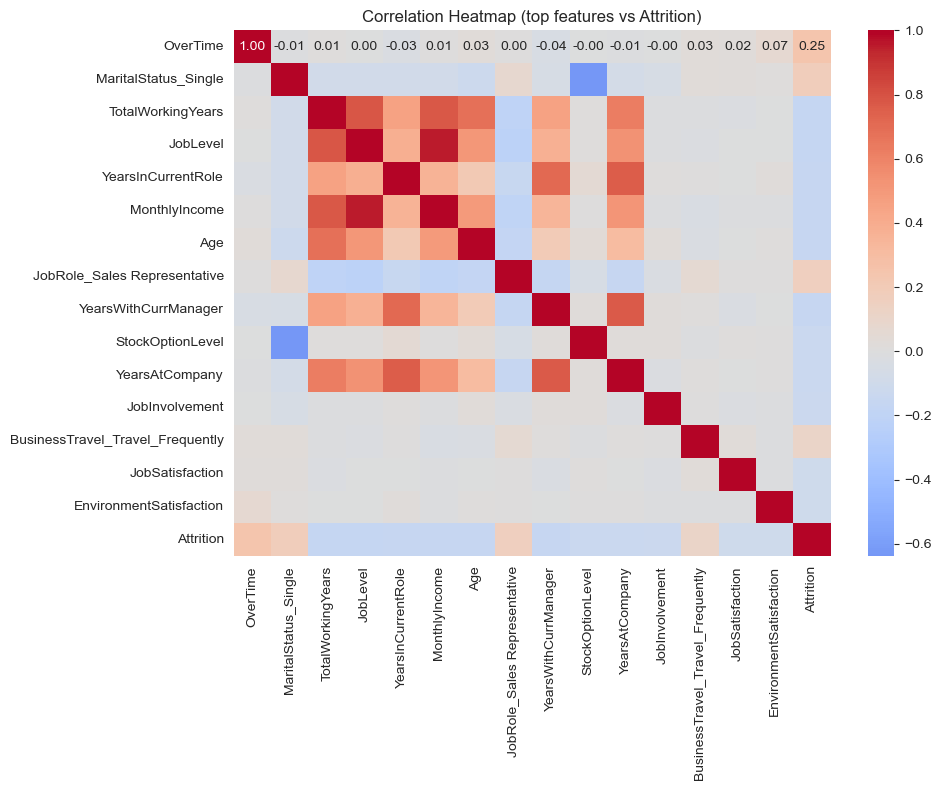

Features most correlated with Attrition:


Attrition                       1.000000
OverTime                        0.246118
MaritalStatus_Single            0.175419
TotalWorkingYears              -0.171063
JobLevel                       -0.169105
YearsInCurrentRole             -0.160545
MonthlyIncome                  -0.159840
Age                            -0.159205
JobRole_Sales Representative    0.157234
YearsWithCurrManager           -0.156199
Name: Attrition, dtype: float64

In [18]:
plt.figure(figsize=(10, 8))
top_corr = df_clean.corr(numeric_only=True)["Attrition"].sort_values(key=abs, ascending=False)
top_features = top_corr.index[1:16]  # skip Attrition itself, take top 15
corr_matrix = df_clean[top_features.tolist() + ["Attrition"]].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (top features vs Attrition)")
plt.tight_layout()
plt.savefig("charts/06_correlation_heatmap.png", dpi=150)
plt.show()

print("Features most correlated with Attrition:")
top_corr.head(10)


**Key takeaway:** no single factor strongly drives attrition on its own
(all correlations are below 0.3). `OverTime`, being `Single`, and having fewer
`TotalWorkingYears` / lower `JobLevel` / lower `MonthlyIncome` / younger `Age`
show the clearest — but still modest — links. This matches what we'll likely
see later in clustering: attrition risk is a mix of many small signals rather
than one dominant cause.